In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import linalg
from scipy.spatial.distance import cdist
import os
from PIL import Image
import math

A.2: Recover Homographies

In [17]:
#part2 ComputeH function 
def computeH1(im1_pts,im2_pts): 
    im1_pts = np.array(im1_pts)
    im2_pts = np.array(im2_pts)
    n = im1_pts.shape[0]
    
    if n < 4:
        raise ValueError("At least 4 point correspondences are required")
    
    A = []
    for i in range(n): 
        x,y = im1_pts[i]
        xp, yp = im2_pts[i]

        #Ah = 0
        A.append([x, y, 1, 0, 0, 0, -xp*x, -xp*y, -xp])
        A.append([0, 0, 0, x, y, 1, -yp*x, -yp*y, -yp])

    A = np.array(A)
    U, S, Vt = np.linalg.svd(A)
    h = Vt[-1, :]
    H = h.reshape(3, 3)
    
    # normalize so that H[2,2] = 1 (scale the entire matrix)
    H = H / H[2, 2]
    
    return H

In [184]:
def computeH_simple(im1_pts, im2_pts):
    """
    Simple homography computation using Ah = b formulation
    where h = [h11, h12, h13, h21, h22, h23, h31, h32] and h33 = 1
    """
    im1_pts = np.array(im1_pts)
    im2_pts = np.array(im2_pts)
    n = im1_pts.shape[0]
    
    if n < 4:
        raise ValueError("At least 4 point correspondences are required")
    
    # Build A and b matrices
    A = []
    b = []
    
    for i in range(n):
        x, y = im1_pts[i]
        xp, yp = im2_pts[i]
        
        # Equation for x': h11*x + h12*y + h13 - h31*x*xp - h32*y*xp = xp
        A.append([x, y, 1, 0, 0, 0, -xp*x, -xp*y])
        b.append(xp)
        
        # Equation for y': h21*x + h22*y + h23 - h31*x*yp - h32*y*yp = yp
        A.append([0, 0, 0, x, y, 1, -yp*x, -yp*y])
        b.append(yp)
    
    A = np.array(A)
    b = np.array(b)
    
    # Solve Ah = b
    if A.shape[0] == A.shape[1]:  # Square matrix (exactly 8 equations)
        h = np.linalg.solve(A, b)
    else:  # Overdetermined system
        h = np.linalg.lstsq(A, b, rcond=None)[0]
    
    # Build the 3x3 homography matrix with h33 = 1
    H = np.array([
        [h[0], h[1], h[2]],    # h11, h12, h13
        [h[3], h[4], h[5]],    # h21, h22, h23  
        [h[6], h[7], 1.0]      # h31, h32, h33=1
    ])
    
    return H

In [185]:
def computeH_ransac_conservative(im1_pts, im2_pts):
    """RANSAC with conservative settings for extreme perspective"""
    from skimage.measure import ransac
    from skimage.transform import ProjectiveTransform
    
    im1_pts = np.array(im1_pts)
    im2_pts = np.array(im2_pts)
    
    # Conservative RANSAC parameters
    model_robust, inliers = ransac(
        (im1_pts, im2_pts),
        ProjectiveTransform, 
        min_samples=6,  # Use more points for estimation
        residual_threshold=2.0,  # Tight threshold
        max_trials=2000  # More trials
    )
    
    inlier_count = np.sum(inliers)
    print(f"RANSAC found {inlier_count} inliers out of {len(im1_pts)} points")
    
    if inlier_count < 6:
        print("Too few inliers, trying relaxed parameters...")
        model_robust, inliers = ransac(
            (im1_pts, im2_pts),
            ProjectiveTransform, 
            min_samples=4,
            residual_threshold=5.0,  # Relaxed threshold
            max_trials=1000
        )
        inlier_count = np.sum(inliers)
        print(f"Relaxed RANSAC found {inlier_count} inliers")
    
    if inlier_count < 4:
        raise ValueError("Insufficient inliers found")
    
    # Get the homography matrix from the model
    H = model_robust.params
    H = H / H[2, 2]  # Normalize
    
    return H

A.3: Warp the Images

In [186]:
#helper funcitons 
def get_output_size(im, H): 
    h, w = im.shape[:2]

    corner = np.array([[0,0, 1], [w-1, 0, 1], [w-1, h-1, 1], [0, h-1, 1]], dtype=np.float32)

    transformed_corners = (H @ corner.T).T #result 3 x 4 transpose to 4 x 3
    #first two cols divide by the third to create homogenous coord 
    #use [2:3] instead of [2] since we want a column vector not a flat array
    transformed_corners = transformed_corners[:, :2] / transformed_corners[:, 2:3] 

    min_x = np.floor(np.min(transformed_corners[:, 0])).astype(int)
    max_x = np.ceil(np.max(transformed_corners[:, 0])).astype(int)
    min_y = np.floor(np.min(transformed_corners[:, 1])).astype(int)
    max_y = np.ceil(np.max(transformed_corners[:, 1])).astype(int)

    output_width = max_x - min_x + 1 #inclusive 
    output_height = max_y - min_y + 1 

    return output_width, output_height, (min_x, min_y)

def nearest_neighbor_interp(im, x, y): 
    h, w = im.shape[:2]

    x_round = np.round(x).astype(int)
    y_round = np.round(y).astype(int)

    x_round = np.clip(x_round, 0, w-1)
    y_round = np.clip(y_round, 0, h-1)

    return im[y_round, x_round]

def bilinear_interp(im, x, y): 
    h, w = im.shape[:2]

    x0 = np.floor(x).astype(int)
    x1 = x0 + 1 
    y0 = np.floor(y).astype(int)
    y1 = y0 + 1

    x0 = np.clip(x0, 0, w-1)
    x1 = np.clip(x1, 0, w-1)
    y0 = np.clip(y0, 0, h-1)
    y1 = np.clip(y1, 0, h-1)

    wa = (x1 - x) * (y1 - y)
    wb = (x1 - x) * (y - y0)
    wc = (x - x0) * (y1 - y)
    wd = (x - x0) * (y - y0)

    if len(im.shape) == 3:  #add None to prevent shape mismatch
        interpolated = (wa[:, :, None] * im[y0, x0] +
                       wb[:, :, None] * im[y1, x0] +
                       wc[:, :, None] * im[y0, x1] +
                       wd[:, :, None] * im[y1, x1])
    else: 
        interpolated = (wa * im[y0, x0] +
                       wb * im[y1, x0] +
                       wc * im[y0, x1] +
                       wd * im[y1, x1])
        
    return interpolated.astype(im.dtype)

In [187]:
def debug_get_output_size(im, H):
    """Debug the output size calculation"""
    h, w = im.shape[:2]
    
    # Get the four corners of the image
    corners = np.array([[0, 0], [w-1, 0], [w-1, h-1], [0, h-1]], dtype=np.float32)
    corners_homo = np.column_stack([corners, np.ones(4)])
    
    # Transform corners using homography
    transformed_corners = (H @ corners_homo.T).T
    transformed_corners = transformed_corners[:, :2] / transformed_corners[:, 2:3]
    
    print("Original corners:")
    print(corners)
    print("Transformed corners:")
    print(transformed_corners)
    
    # Calculate bounding box
    min_x = np.floor(np.min(transformed_corners[:, 0])).astype(int)
    max_x = np.ceil(np.max(transformed_corners[:, 0])).astype(int)
    min_y = np.floor(np.min(transformed_corners[:, 1])).astype(int)
    max_y = np.ceil(np.max(transformed_corners[:, 1])).astype(int)
    
    print(f"Bounding box: x[{min_x}, {max_x}], y[{min_y}, {max_y}]")
    print(f"min_pair would be: ({min_x}, {min_y})")
    
    output_width = max_x - min_x + 1
    output_height = max_y - min_y + 1
    
    return output_width, output_height, (min_x, min_y)


In [188]:
def warpImage(im, H, interp_func): 
    output_w, output_h, min_pair = debug_get_output_size(im, H)

    if len(im.shape) == 3:
        output = np.zeros((output_h, output_w, 4), dtype=im.dtype)  # RGBA
    else:
        output = np.zeros((output_h, output_w, 2), dtype=im.dtype)

    #assign point coord values 
    y_out, x_out = np.mgrid[0:output_h, 0:output_w]
    x_out_shifted = x_out + min_pair[0]
    y_out_shifted = y_out + min_pair[1]

    #coords_out = np.stack([x_out, y_out, np.ones_like(x_out)], axis=-1)
    coords_out = np.stack([x_out_shifted, y_out_shifted, np.ones_like(x_out_shifted)], axis=-1)

    # coords_out = np.stack([x_out_shifted, y_out_shifted, np.ones_like(x_out)], axis=-1)

    H_inv = np.linalg.inv(H)
    coords_src = (H_inv @ coords_out.reshape(-1, 3).T).T.reshape(output_h, output_w, 3)

    coords_src = coords_src[:, :, :2]/coords_src[:,:,2:3]

    x_src = coords_src[:, :, 0]
    y_src = coords_src[:, :, 1]

    h_src, w_src = im.shape[:2]
    mask = (x_src >= 0) & (x_src <= w_src-1) & (y_src >= 0) & (y_src <= h_src-1)

    if len(im.shape) == 3: 
        for c in range(3): 
            output[:,:,c] = interp_func(im[:,:,c], x_src, y_src)
            output[:,:,c] = output[:,:,c] * mask
        output[:, :, 3] = (mask * 255).astype(im.dtype)  #transparent = 0 
    else: 
        output[:, :, 0] = interp_func(im[:,:,0], x_src, y_src)
        output[:, :, 1] = (mask * 255).astype(im.dtype) 
        
    return output 

In [197]:
# Debug your current homography
print("=== Debugging Output Size ===")
import json

img = plt.imread('../data/IMG_8843r.jpg') 
with open('../data/chairsR.json', 'r') as f:
    warped_points = json.load(f)

original_pts = np.array(warped_points["im1Points"])
new_pts = np.array(warped_points["im2Points"])
H = computeH_simple(original_pts,new_pts)

output_w, output_h, min_pair = debug_get_output_size(img, H)
print(f"Output size: {output_w} x {output_h}")
print(f"min_pair: {min_pair}")

=== Debugging Output Size ===
Original corners:
[[   0.    0.]
 [1499.    0.]
 [1499. 1124.]
 [   0. 1124.]]
Transformed corners:
[[1557.60211613 1252.76580878]
 [ 797.73769732  264.27362674]
 [ 844.59626438  856.39835936]
 [1469.2103731    57.88832757]]
Bounding box: x[797, 1558], y[57, 1253]
min_pair would be: (797, 57)
Output size: 762 x 1197
min_pair: (np.int64(797), np.int64(57))


In [198]:
#Part 3 functions
def warpImageNearestNeighbor(im, H): 
    return warpImage(im, H, nearest_neighbor_interp)
def warpImageBilinear(im, H):
    return warpImage(im, H, bilinear_interp)

In [199]:
def display(im_original, im_warped, interp_func, title="Image Warping Result"):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    # Display original image
    ax1.imshow(im_original)
    ax1.set_title('Original Image', fontweight='bold')
    ax1.axis('off')
    
    # Display warped image
    if len(im_warped.shape) == 3 and im_warped.shape[2] >= 3:
        # Color image with alpha channel
        ax2.imshow(im_warped[:, :, :3])
    else:
        # Grayscale image
        ax2.imshow(im_warped[:, :, 0], cmap='gray')
    
    ax2.set_title(f'Warped Image ({interp_func})', fontweight='bold')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

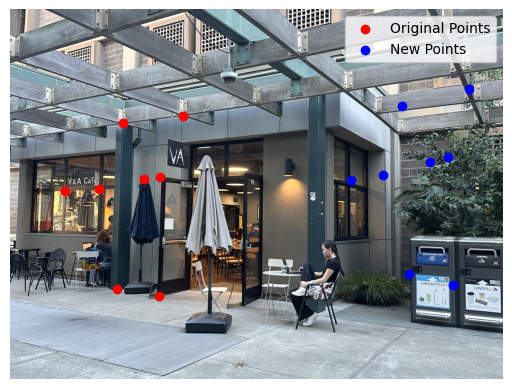

In [206]:
import json

img = plt.imread('../data/IMG_8848.jpg') 
with open('../data/VA.json','r') as f:
    warped_points = json.load(f)

original_pts = np.array(warped_points["im1Points"])
new_pts = np.array(warped_points["im2Points"])


H = computeH_simple(original_pts,new_pts)
#imwarped_nn = warpImageNearestNeighbor(img,H)
#imwarped_bil = warpImageBilinear(img,H)

# Plot the image
fig, ax = plt.subplots()

# Plot the image
ax.imshow(img)

# Plot the points on the image
ax.scatter(original_pts[:, 0], original_pts[:, 1], c='r', label='Original Points')
ax.scatter(new_pts[:, 0], new_pts[:, 1], c='b', label='New Points')

ax.legend()
ax.axis('off')
plt.show()

Homography matrix:
[[ 5.07748275e-01  5.46242689e-02  2.31456956e+03]
 [-2.34457493e-01  8.92355269e-01  8.87639985e+01]
 [-1.26177642e-04 -1.45831537e-06  1.00000000e+00]]
Output size: 6983 x 5526
This is 38,588,058 pixels!
Original corners:
[[   0.    0.]
 [4031.    0.]
 [4031. 3023.]
 [   0. 3023.]]
Transformed corners:
[[ 2314.56955783    88.76399855]
 [ 8875.65887579 -1742.72003089]
 [ 9295.10489921  3781.05004686]
 [ 2490.67884886  2798.69197354]]
Bounding box: x[2314, 9296], y[-1743, 3782]
min_pair would be: (2314, -1743)


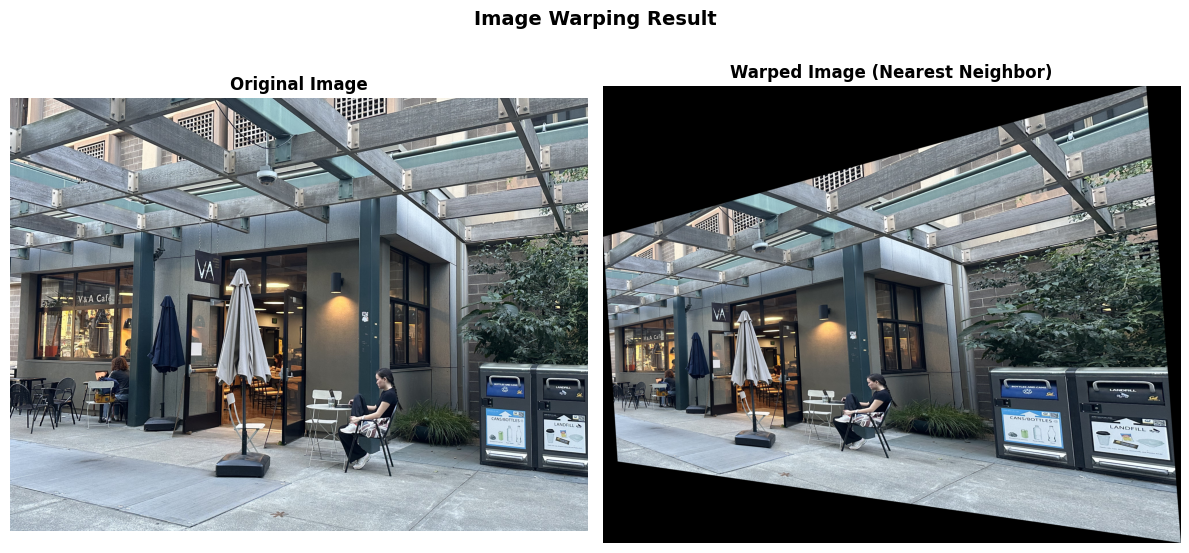

In [207]:
print(f"Homography matrix:\n{H}")
output_w, output_h, min_pair = get_output_size(img, H)
print(f"Output size: {output_w} x {output_h}")
print(f"This is {output_w * output_h:,} pixels!")

imwarped_nn = warpImageNearestNeighbor(img,H)
#imwarped_bil = warpImageBilinear(img, H)


display(img, imwarped_nn, "Nearest Neighbor")

#display(img, imwarped_bil, "Bilinear")


In [208]:
def debug_warp_coordinates(im, H, min_pair):
    """Debug the coordinate transformation"""
    output_w, output_h, min_pair = debug_get_output_size(im, H)
    
    # Test a few points
    test_points = [
        (0, 0),  # top-left output
        (output_w-1, 0),  # top-right
        (0, output_h-1),  # bottom-left  
        (output_w-1, output_h-1),  # bottom-right
    ]
    
    H_inv = np.linalg.inv(H)
    
    print("=== Coordinate Debug ===")
    for x_out, y_out in test_points:
        # Global coordinates
        x_global = x_out + min_pair[0]
        y_global = y_out + min_pair[1]
        
        # Transform to source
        dst_homo = np.array([x_global, y_global, 1.0])
        src_homo = H_inv @ dst_homo
        src_coord = src_homo[:2] / src_homo[2]
        
        print(f"Output ({x_out},{y_out}) -> Global ({x_global:.1f},{y_global:.1f}) -> Source ({src_coord[0]:.1f},{src_coord[1]:.1f})")
        
        # Check if within source bounds
        h_src, w_src = im.shape[:2]
        in_bounds = (0 <= src_coord[0] < w_src) and (0 <= src_coord[1] < h_src)
        print(f"  Within source bounds: {in_bounds}")

# Use it:
debug_warp_coordinates(img, H, min_pair)

Original corners:
[[   0.    0.]
 [4031.    0.]
 [4031. 3023.]
 [   0. 3023.]]
Transformed corners:
[[ 2314.56955783    88.76399855]
 [ 8875.65887579 -1742.72003089]
 [ 9295.10489921  3781.05004686]
 [ 2490.67884886  2798.69197354]]
Bounding box: x[2314, 9296], y[-1743, 3782]
min_pair would be: (2314, -1743)
=== Coordinate Debug ===
Output (0,0) -> Global (2314.0,-1743.0) -> Source (143.3,-1985.4)
  Within source bounds: False
Output (6982,0) -> Global (9296.0,-1743.0) -> Source (4151.4,61.3)
  Within source bounds: False
Output (0,5525) -> Global (2314.0,3782.0) -> Source (-305.0,4195.8)
  Within source bounds: False
Output (6982,5525) -> Global (9296.0,3782.0) -> Source (4031.2,3023.5)
  Within source bounds: True


A.4: Blend the Images into a Mosaic

In [209]:
from scipy import ndimage

def create_distance_weights(mask):
    if not np.any(mask):
        return np.zeros_like(mask, dtype=np.float32)
    
    dist_transform = ndimage.distance_transform_edt(mask)
    
    if np.max(dist_transform) > 0:
        weights = dist_transform / np.max(dist_transform)
    else:
        weights = mask.astype(np.float32)
    
    return weights

In [156]:
def compose_mosaic_proper_blending(img1, img2, H2, interp_func):
 
    h2, w2 = img2.shape[:2]
    corners2 = np.array([[0, 0, 1], [w2-1, 0, 1], [w2-1, h2-1, 1], [0, h2-1, 1]], dtype=np.float32)
    transformed_corners2 = corners2 @ H2.T
    transformed_corners2 = transformed_corners2[:, :2] / transformed_corners2[:, 2:3]

    h1, w1 = img1.shape[:2]
    corners1 = np.array([[0, 0], [w1-1, 0], [w1-1, h1-1], [0, h1-1]], dtype=np.float32)

    all_corners = np.vstack([corners1, transformed_corners2])
    min_x, min_y = np.floor(np.min(all_corners, axis=0)).astype(int)
    max_x, max_y = np.ceil(np.max(all_corners, axis=0)).astype(int)
    mosaic_width = max_x - min_x + 1
    mosaic_height = max_y - min_y + 1

    print(f"Mosaic size: {mosaic_width} x {mosaic_height}")

    T = np.array([[1, 0, -min_x],
                  [0, 1, -min_y],
                  [0, 0, 1]])

    H2_adjusted = T @ H2

    warped_img2 = warpImage(img2, H2_adjusted, interp_func)
    print(f"Warped image size: {warped_img2.shape}")

    offset_x, offset_y = -min_x, -min_y
    
    canvas = np.zeros((mosaic_height, mosaic_width, 4), dtype=np.uint8)
    weight_map = np.zeros((mosaic_height, mosaic_width), dtype=np.float32)
    color_sum = np.zeros((mosaic_height, mosaic_width, 3), dtype=np.float32)
    
    # Place img1
    y1_start, y1_end = offset_y, offset_y + h1
    x1_start, x1_end = offset_x, offset_x + w1
    
    # Simple weights for img1 (all 1.0 for now)
    img1_weights = np.ones((h1, w1), dtype=np.float32)
    
    for c in range(3):
        color_sum[y1_start:y1_end, x1_start:x1_end, c] += (
            img1[:, :, c].astype(np.float32) * img1_weights
        )
    weight_map[y1_start:y1_end, x1_start:x1_end] += img1_weights
    canvas[y1_start:y1_end, x1_start:x1_end, 3] = 255
    
    h_warped, w_warped = warped_img2.shape[:2]
    warped_region = warped_img2[:h_warped, :w_warped]
    warped_mask = warped_region[:, :, 3] > 0
    
    if np.any(warped_mask):
        warped_weights = warped_mask.astype(np.float32)
        
        for c in range(3):
            color_sum[:h_warped, :w_warped, c] += (
                warped_region[:, :, c].astype(np.float32) * warped_weights
            )
        weight_map[:h_warped, :w_warped] += warped_weights
        canvas[:h_warped, :w_warped, 3] = np.maximum(
            canvas[:h_warped, :w_warped, 3], 
            warped_region[:, :, 3]
        )
    
    valid_weights = weight_map > 0
    for c in range(3):
        canvas[:, :, c][valid_weights] = np.clip(
            color_sum[:, :, c][valid_weights] / weight_map[valid_weights], 
            0, 255
        ).astype(np.uint8)

    # Auto-crop 
    alpha_channel = canvas[:, :, 3]
    rows = np.any(alpha_channel > 0, axis=1)
    cols = np.any(alpha_channel > 0, axis=0)
    
    if np.any(rows) and np.any(cols):
        ymin, ymax = np.where(rows)[0][[0, -1]]
        xmin, xmax = np.where(cols)[0][[0, -1]]
        
        pad = 10
        ymin = max(0, ymin - pad)
        ymax = min(mosaic_height-1, ymax + pad)
        xmin = max(0, xmin - pad)
        xmax = min(mosaic_width-1, xmax + pad)
        
        cropped_canvas = canvas[ymin:ymax+1, xmin:xmax+1]
        print(f"Cropped from {mosaic_width}x{mosaic_height} to {cropped_canvas.shape[1]}x{cropped_canvas.shape[0]}")
    else:
        cropped_canvas = canvas
        print("No cropping applied")

    return cropped_canvas

In [157]:
def warpImage(im, H, interp_func): 
    output_w, output_h, min_pair = get_output_size_fixed(im, H)

    if len(im.shape) == 3:
        output = np.zeros((output_h, output_w, 4), dtype=im.dtype)  # RGBA
    else:
        output = np.zeros((output_h, output_w, 2), dtype=im.dtype)

    #assign point coord values 
    y_out, x_out = np.mgrid[0:output_h, 0:output_w]
    

    coords_out = np.stack([x_out, y_out, np.ones_like(x_out)], axis=-1)

    H_inv = np.linalg.inv(H)
    coords_src = (coords_out @ H_inv.T)
    coords_src = coords_src[:, :, :2]/coords_src[:,:,2:3]

    x_src = coords_src[:, :, 0]
    y_src = coords_src[:, :, 1]

    h_src, w_src = im.shape[:2]
    mask = (x_src >= 0) & (x_src <= w_src-1) & (y_src >= 0) & (y_src <= h_src-1)

    if len(im.shape) == 3: 
        for c in range(3): 
            output[:,:,c] = interp_func(im[:,:,c], x_src, y_src)
            output[:,:,c] = output[:,:,c] * mask
        output[:, :, 3] = (mask * 255).astype(im.dtype)  #transparent = 0 
    else: 
        output[:, :, 0] = interp_func(im[:,:,0], x_src, y_src)
        output[:, :, 1] = (mask * 255).astype(im.dtype) 
        
    return output 

def warpImageNearestNeighbor(im, H): 
    return warpImage(im, H, nearest_neighbor_interp)
def warpImageBilinear(im, H):
    return warpImage(im, H, bilinear_interp)

In [158]:
def get_H(json_path): 
    with open(json_path, 'r') as f:
        warped_points = json.load(f)

    original_pts = np.array(warped_points["im1Points"])
    new_pts = np.array(warped_points["im2Points"])


    H = computeH_solve_normalized(original_pts,new_pts)
    return H, original_pts, new_pts

In [159]:
# Get your homography and points
H, original_pts, new_pts = get_H('../data/chairsR.json')

img1 = plt.imread('../data/IMG_8844r.jpg') 
img2 = plt.imread('../data/IMG_8843r.jpg') 

# Call the function with points
mosaic = compose_mosaic_proper_blending(img1, img2, H, nearest_neighbor_interp)


Mosaic size: 2308 x 1990
Original bounds: x[821, 2307], y[0, 1989]
Offsets: x=-821, y=0
Warped image size: (1990, 1487, 4)
Cropped from 2308x1990 to 1510x1990


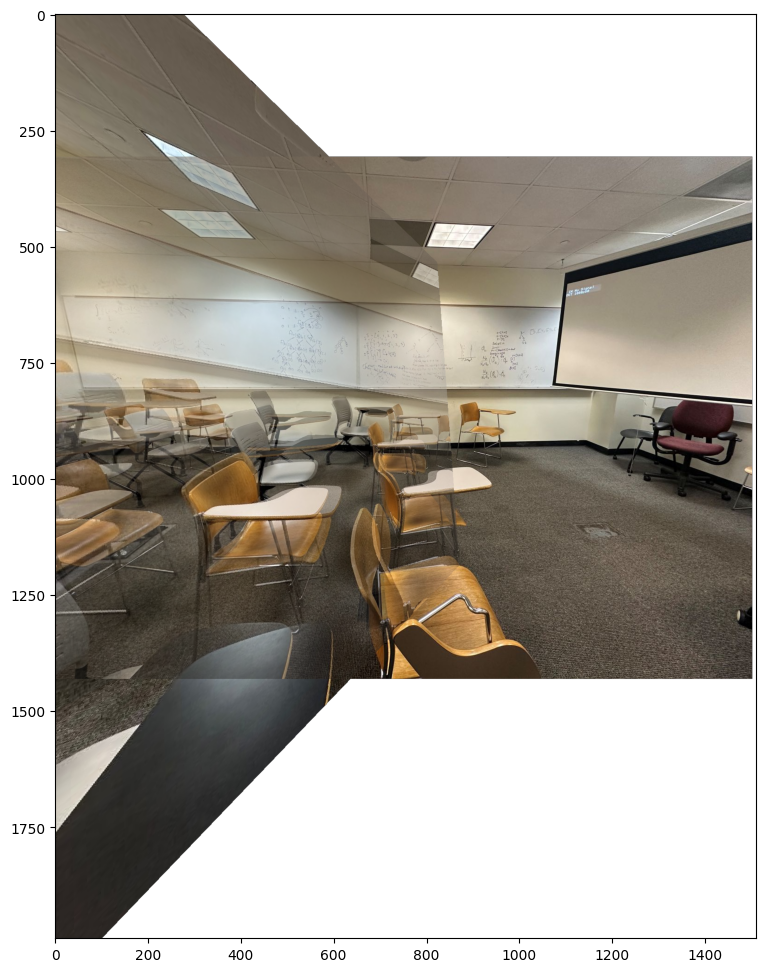

In [169]:

fig, axes = plt.subplots(figsize=(18, 12))
plt.imshow(mosaic)
plt.show()

In [45]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

def create_blending_mask(warped_img, reference_img):
    """
    Create smooth blending mask using distance transform
    """
    # Create masks from non-zero pixels
    mask_warped = np.any(warped_img > 0, axis=2).astype(np.uint8)
    mask_reference = np.any(reference_img > 0, axis=2).astype(np.uint8)
    
    # Compute distance transforms
    dist_warped = ndimage.distance_transform_edt(mask_warped)
    dist_reference = ndimage.distance_transform_edt(mask_reference)
    
    # Create smooth alpha mask
    # Where both images overlap, use distance-based weights
    # Where only one image exists, use that image completely
    alpha_mask = np.zeros_like(dist_warped, dtype=np.float32)
    
    # Areas where both images have content
    overlap_mask = (mask_warped > 0) & (mask_reference > 0)
    if np.any(overlap_mask):
        total_dist = dist_warped[overlap_mask] + dist_reference[overlap_mask]
        alpha_mask[overlap_mask] = dist_warped[overlap_mask] / total_dist
    
    # Areas where only warped image has content
    warped_only = (mask_warped > 0) & (mask_reference == 0)
    alpha_mask[warped_only] = 1.0
    
    # Areas where only reference has content remain 0
    
    return alpha_mask

def blend_images_weighted(img1, img2, alpha_mask):
    """
    Blend images using weighted average with smooth alpha mask
    """
    # Ensure alpha mask has 3 channels for RGB
    if len(alpha_mask.shape) == 2:
        alpha_mask = alpha_mask[:, :, np.newaxis]
    
    # Convert to float for blending
    img1_float = img1.astype(np.float32)
    img2_float = img2.astype(np.float32)
    
    # Weighted blending
    blended = img1_float * alpha_mask + img2_float * (1.0 - alpha_mask)
    
    return np.clip(blended, 0, 255).astype(np.uint8)

def compose_mosaic_distance_blend(img1, img2, H, interp_func):
    """
    Compose mosaic using distance-transform based blending 
    """
    
    # Step 1: Calculate mosaic bounding box
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    # Transform corners of both images
    corners1 = np.array([[0, 0, 1], [w1-1, 0, 1], [w1-1, h1-1, 1], [0, h1-1, 1]], dtype=np.float32)
    corners2 = np.array([[0, 0, 1], [w2-1, 0, 1], [w2-1, h2-1, 1], [0, h2-1, 1]], dtype=np.float32)
    
    transformed_corners2 = (H @ corners2.T).T
    transformed_corners2 = transformed_corners2[:, :2] / transformed_corners2[:, 2:3]
    
    all_corners = np.vstack([corners1[:, :2], transformed_corners2])
    
    min_x, min_y = np.floor(np.min(all_corners, axis=0)).astype(int)
    max_x, max_y = np.ceil(np.max(all_corners, axis=0)).astype(int)
    
    mosaic_width = max_x - min_x + 1
    mosaic_height = max_y - min_y + 1
    
    print(f"Mosaic size: {mosaic_width} x {mosaic_height}")

    # Step 2: Adjust homography for mosaic coordinates
    T = np.array([[1, 0, -min_x],
                  [0, 1, -min_y],
                  [0, 0, 1]])
    H_adjusted = T @ H

    # Step 3: Warp img2
    warped_img2 = warpImage(img2, H_adjusted, interp_func)
    print(f"Warped image size: {warped_img2.shape}")

    # Step 4: Create canvas and place images
    canvas = np.zeros((mosaic_height, mosaic_width, 3), dtype=np.uint8)
    
    # Place img1 (reference image)
    offset_x, offset_y = -min_x, -min_y
    y1_start, y1_end = offset_y, offset_y + h1
    x1_start, x1_end = offset_x, offset_x + w1
    canvas[y1_start:y1_end, x1_start:x1_end] = img1

    # Step 5: Get regions for blending
    h_warped, w_warped = warped_img2.shape[:2]
    warped_rgb = warped_img2[:, :, :3]  # Extract RGB
    
    # Get the corresponding region from canvas
    canvas_region = canvas[:h_warped, :w_warped]
    
    # Step 6: Create blending mask and blend
    alpha_mask = create_blending_mask(warped_rgb, canvas_region)
    
    # Apply blending
    blended_region = blend_images_weighted(warped_rgb, canvas_region, alpha_mask)
    
    # Update canvas with blended result
    canvas[:h_warped, :w_warped] = blended_region

    # Step 7: Auto-crop to remove empty borders
    non_empty_mask = np.any(canvas > 0, axis=2)
    rows = np.any(non_empty_mask, axis=1)
    cols = np.any(non_empty_mask, axis=0)
    
    if np.any(rows) and np.any(cols):
        ymin, ymax = np.where(rows)[0][[0, -1]]
        xmin, xmax = np.where(cols)[0][[0, -1]]
        
        # Add small padding
        pad = 10
        ymin = max(0, ymin - pad)
        ymax = min(mosaic_height-1, ymax + pad)
        xmin = max(0, xmin - pad)
        xmax = min(mosaic_width-1, xmax + pad)
        
        canvas = canvas[ymin:ymax+1, xmin:xmax+1]
        print(f"Cropped to: {canvas.shape[1]} x {canvas.shape[0]}")

    return canvas


Mosaic size: 2308 x 1990
Warped image size: (1990, 1487, 4)
Cropped to: 1510 x 1990


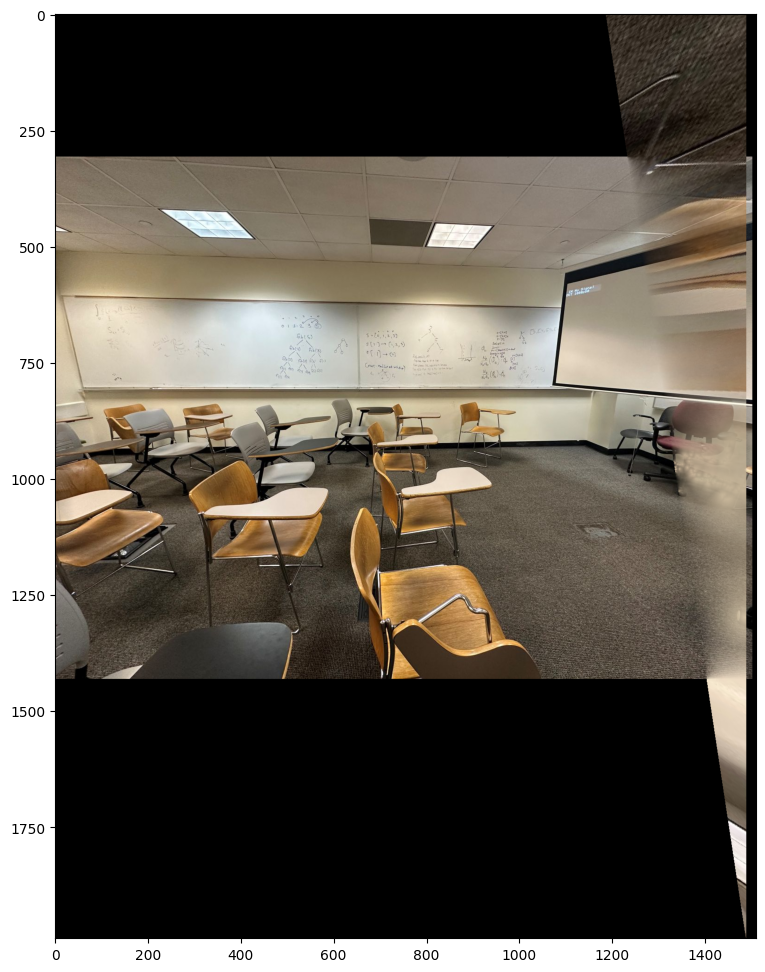

In [143]:
# Get your homography and points
H, original_pts, new_pts = get_H('../data/chairsR.json')

img1 = plt.imread('../data/IMG_8844r.jpg') 
img2 = plt.imread('../data/IMG_8843r.jpg') 

# Call the function with points
mosaic = compose_mosaic_distance_blend(img1, img2, H, nearest_neighbor_interp)

#mosaic = compose_mosaic_distance_blend(img1, img2, H, bilinear_interp)
fig, axes = plt.subplots(figsize=(18, 12))
plt.imshow(mosaic)
plt.show()